# Εισαγωγή

Η παρακάτω αναφορά αποτελεί εργασία για το μάθημα **ΕΙΔΙΚΑ ΘΕΜΑΤΑ ΒΙΟΣΤΑΤΙΣΤΙΚΗΣ**  του τμήματος Πληροφορικής με Εφαρμογές στη Βιοϊατρική του Πανεπιστημίου Θεσσαλίας για το ακαδημαϊκό έτος 2023-2024. Η εργασία χωρίζεται σε 5 μέρη τα οποία αναλύονται παρακάτω:



# Κεφάλαιο 1: Ανάλυση Δεδομένων

In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
# Load the dataset into a DataFrame
df = pd.read_csv('heart.csv')

# Check the dimensions of the dataset (rows, columns)
print(f"Dataset dimensions: {df.shape}")

# Check for missing values
print(f"Missing values:\n{df.isnull().sum()}")

# Check data types of each column
print(f"Data types:\n{df.dtypes}")

Dataset dimensions: (299, 13)
Missing values:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64
Data types:
age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
DEATH_EVENT                   int64
dtype: object


# Κεφαλαιο : Example Exploratory Data Analysis (EDA)

              age     anaemia  creatinine_phosphokinase    diabetes  \
count  299.000000  299.000000                299.000000  299.000000   
mean    60.833893    0.431438                581.839465    0.418060   
std     11.894809    0.496107                970.287881    0.494067   
min     40.000000    0.000000                 23.000000    0.000000   
25%     51.000000    0.000000                116.500000    0.000000   
50%     60.000000    0.000000                250.000000    0.000000   
75%     70.000000    1.000000                582.000000    1.000000   
max     95.000000    1.000000               7861.000000    1.000000   

       ejection_fraction  high_blood_pressure      platelets  \
count         299.000000           299.000000     299.000000   
mean           38.083612             0.351171  263358.029264   
std            11.834841             0.478136   97804.236869   
min            14.000000             0.000000   25100.000000   
25%            30.000000             0.0

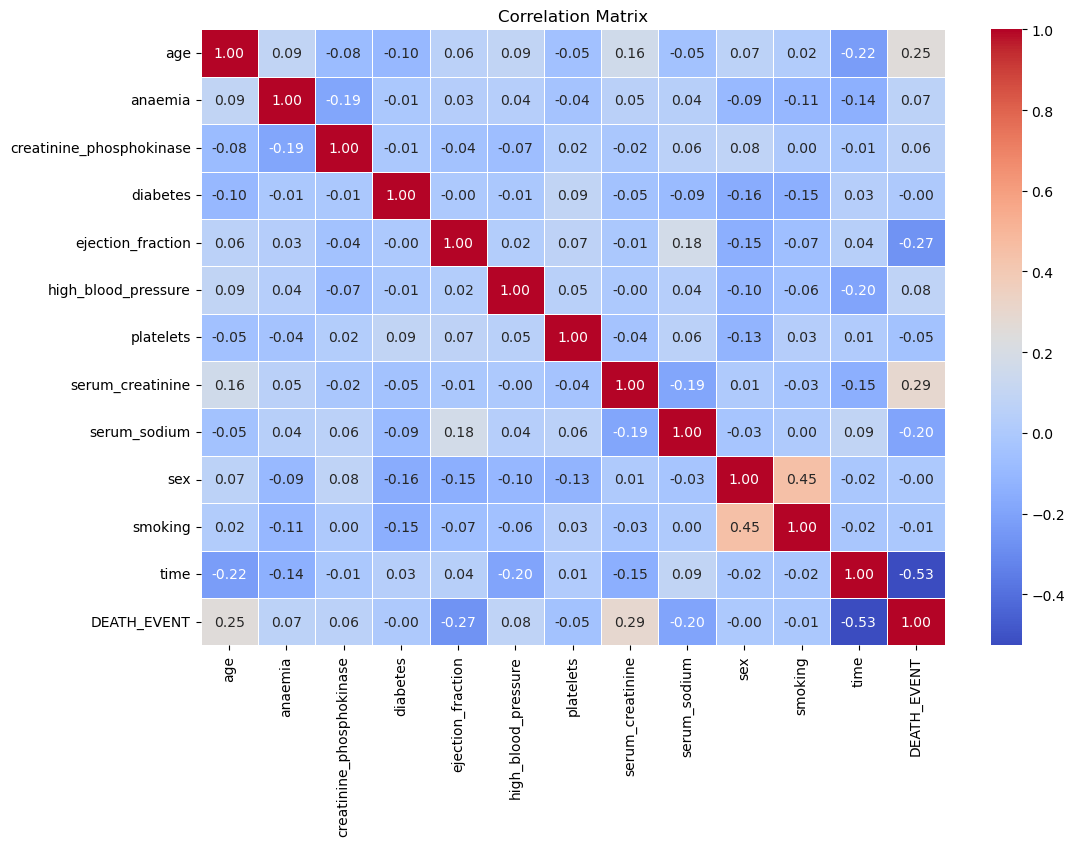

In [8]:


# Summary statistics
summary_stats = df.describe()
print(summary_stats)

# Correlation matrix
corr_matrix = df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()



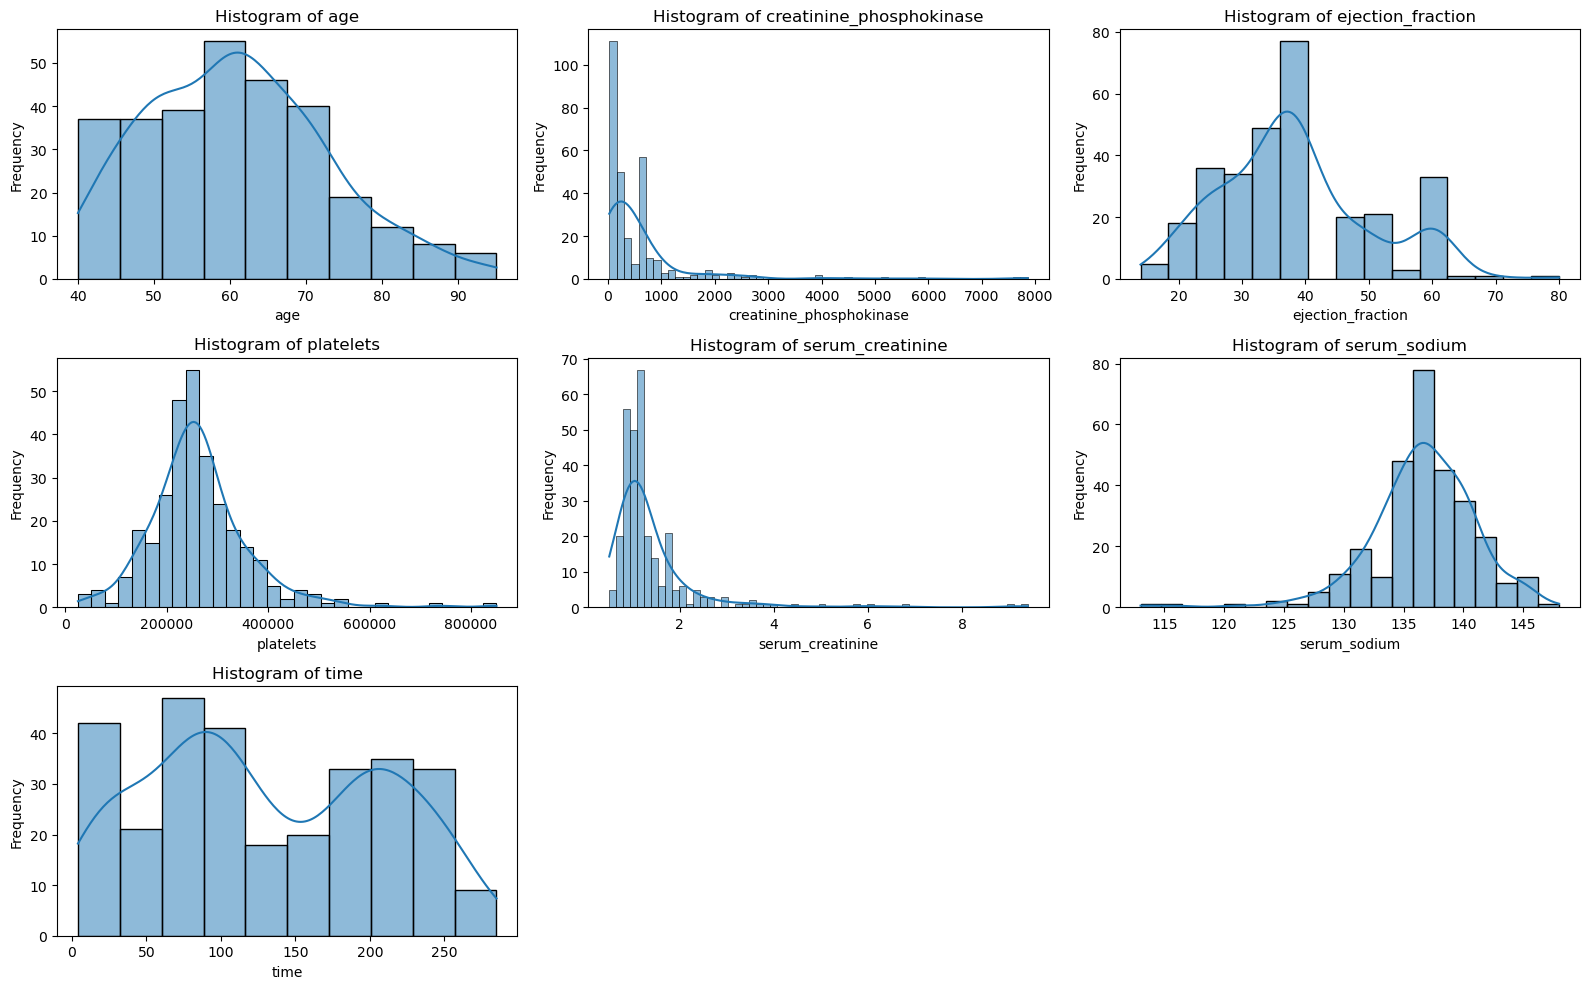

In [30]:
# Histograms for numerical variables
plt.figure(figsize=(16, 10))
numerical_vars = ['age', 'creatinine_phosphokinase', 'ejection_fraction', 'platelets', 'serum_creatinine', 'serum_sodium', 'time']
for i, var in enumerate(numerical_vars, 1):
    plt.subplot(3, 3, i)
    sns.histplot(data=df, x=var, kde=True)
    plt.title(f'Histogram of {var}')
    plt.xlabel(var)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# ΣΥΓΚΡΙΣΗ ΔΕΔΟΜΕΝΩΝ ΚΑΙ ΕΞΑΓΩΓΗ ΑΠΟΤΕΛΕΣΜΑΤΩΝ


# 1. DEATH_EVENT and Age

In [16]:
# Cross-tabulation of DEATH_EVENT and age
bins = [40, 50, 60, 70, 80, 90, 100]  # Adjust bins as needed
df['age_group'] = pd.cut(df['age'], bins=bins)
cross_tab_age = pd.crosstab(df['DEATH_EVENT'], df['age_group'])

print(cross_tab_age)

# Chi-square test
chi2_age, p_age, dof_age, expected_age = chi2_contingency(cross_tab_age)
print(f"Chi-square value: {chi2_age}")
print(f"P-value: {p_age}")


age_group    (40, 50]  (50, 60]  (60, 70]  (70, 80]  (80, 90]  (90, 100]
DEATH_EVENT                                                             
0                  48        63        64        16         5          0
1                  19        25        21        18        10          3
Chi-square value: 24.07567122111169
P-value: 0.000209962508073661


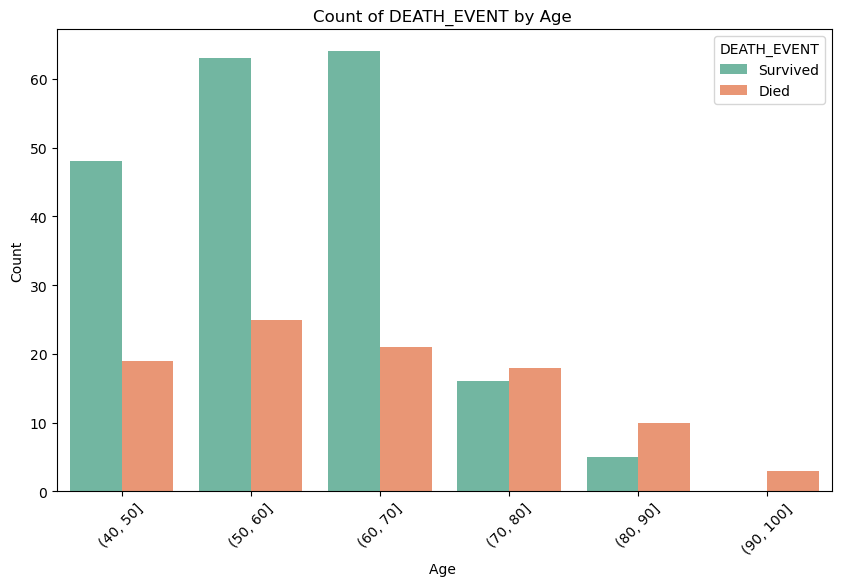

In [19]:
#Plot of death_event by age 
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='age', hue='DEATH_EVENT', palette='Set2')
plt.title('Count of DEATH_EVENT by Age ')
plt.xlabel('Age ')
plt.ylabel('Count')
plt.legend(title='DEATH_EVENT', labels=['Survived', 'Died'])
plt.xticks(rotation=45)
plt.show()


### Ηλικία ως Προγνωστικός Παράγοντας

Βασισμένο στην ανάλυση, οι μεγαλύτερης ηλικίας ασθενείς είναι πιο πιθανό να πεθάνουν (DEATH_EVENT = 1) σε σύγκριση με τους νεότερους ασθενείς στο πλαίσιο της καρδιακής ανεπάρκειας.

**Στατιστική Σημαντικότητα**
Το τεστ chi-square επιβεβαιώνει ότι αυτή η συσχέτιση δεν είναι τυχαία, υποδεικνύοντας μια σημαντική σχέση μεταξύ ηλικίας και θνησιμότητας στο πλαίσιο της καρδιακής ανεπάρκειας (p-value = 0.0002).

Παρακάτω παρατίθεται ο πίνακας συνάφειας για τη μεταβλητή age_group και τον προσδιορισμό DEATH_EVENT:

| Ηλικιακή Ομάδα | DEATH_EVENT = 0 | DEATH_EVENT = 1 |
|----------------|-----------------|-----------------|
| (40, 50]       | 48              | 19              |
| (50, 60]       | 63              | 25              |
| (60, 70]       | 64              | 21              |
| (70, 80]       | 16              | 18              |
| (80, 90]       | 5               | 10              |
| (90, 100]      | 0               | 3               |

**Συμπέρασμα:**
Οι μεγαλύτερης ηλικίας ασθενείς εμφανίζουν αυξημένο κίνδυνο θανάτου σε σύγκριση με τους νεότερους ασθενείς στο πλαίσιο της καρδιακής ανεπάρκειας, όπως υποδεικνύει η σημαντική στατιστική σχέση.


# 2) DEATH_EVENT and Gender

sex           0    1
DEATH_EVENT         
0            71  132
1            34   62
Chi-square value: 0.0
P-value: 1.0


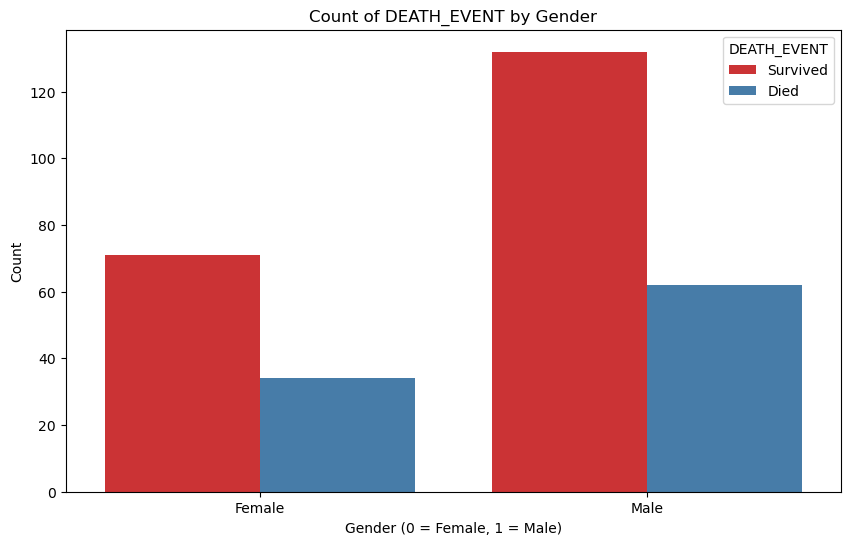

In [19]:
# Cross-tabulation of DEATH_EVENT and sex
cross_tab_sex = pd.crosstab(df['DEATH_EVENT'], df['sex'])

print(cross_tab_sex)

# Chi-square test
from scipy.stats import chi2_contingency

chi2_sex, p_sex, dof_sex, expected_sex = chi2_contingency(cross_tab_sex)
print(f"Chi-square value: {chi2_sex}")
print(f"P-value: {p_sex}")
 
    
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='sex', hue='DEATH_EVENT', palette='Set1')
plt.title('Count of DEATH_EVENT by Gender')
plt.xlabel('Gender (0 = Female, 1 = Male)')
plt.ylabel('Count')
plt.legend(title='DEATH_EVENT', labels=['Survived', 'Died'])
plt.xticks([0, 1], ['Female', 'Male'])
plt.show()


### Ανάλυση της μεταβλητής Sex ως Προγνωστικός Παράγοντας

Βασισμένο στην ανάλυση, ο φύλος δεν φαίνεται να συσχετίζεται σημαντικά με τον κίνδυνο θνησιμότητας σε ασθενείς με καρδιακή ανεπάρκεια . Η στατιστική σημαντικότητα υποδεικνύει ότι οι παρατηρούμενες διαφορές στα ποσοστά θανάτου μεταξύ ανδρών και γυναικών μπορεί να εξαρτώνται από την τυχαιότητα.

Παρακάτω παρατίθεται ο πίνακας συνάφειας για τη μεταβλητή sex και τον προσδιορισμό DEATH_EVENT:

| Φύλο | DEATH_EVENT = 0 | DEATH_EVENT = 1 |
|-------|-----------------|-----------------|
| Άνδρας | 71              | 34              |
| Γυναίκα | 132             | 62              |

**Στατιστική Σημαντικότητα:**
Το υψηλό p-value (p = 1.0) υποδεικνύει ότι δεν υπάρχει στατιστικά σημαντική συσχέτιση μεταξύ του φύλου και της θνησιμότητας στο πλαίσιο της καρδιακής ανεπάρκειας.

**Συμπέρασμα:**
Το φύλο δεν φαίνεται να είναι σημαντικός προγνωστικός παράγοντας για τη θνησιμότητα σε ασθενείς με καρδιακή ανεπάρκεια .


# 3. DEATH_EVENT and Ejection Fraction

In [20]:
# Cross-tabulation of DEATH_EVENT and ejection_fraction
cross_tab_ef = pd.crosstab(df['DEATH_EVENT'], pd.cut(df['ejection_fraction'], bins=5))

print(cross_tab_ef)

# Chi-square test
chi2_ef, p_ef, dof_ef, expected_ef = chi2_contingency(cross_tab_ef)
print(f"Chi-square value: {chi2_ef}")
print(f"P-value: {p_ef}")


ejection_fraction  (13.934, 27.2]  (27.2, 40.4]  (40.4, 53.6]  (53.6, 66.8]  \
DEATH_EVENT                                                                   
0                              21           121            30            30   
1                              38            39            11             7   

ejection_fraction  (66.8, 80.0]  
DEATH_EVENT                      
0                             1  
1                             1  
Chi-square value: 36.39543534477698
P-value: 2.399281648217531e-07


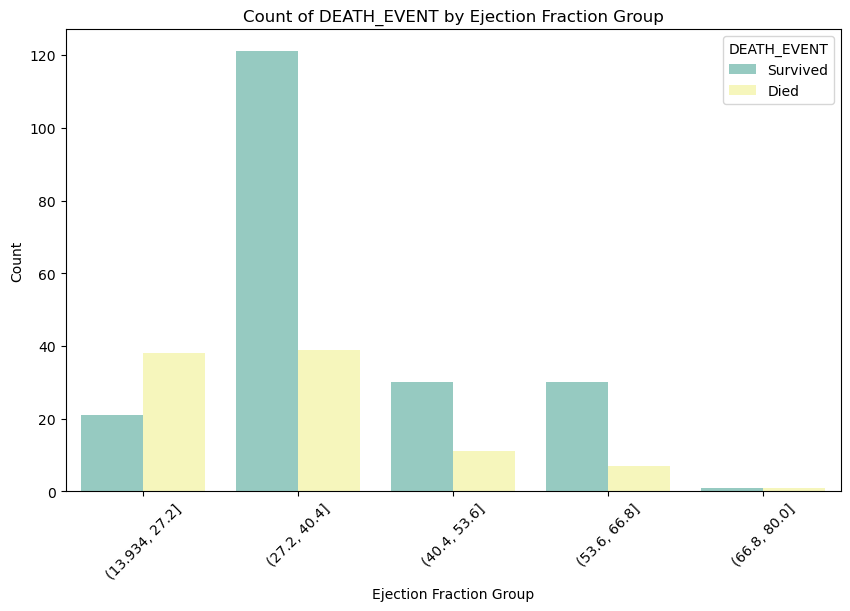

In [21]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x=pd.cut(df['ejection_fraction'], bins=5), hue='DEATH_EVENT', palette='Set3')
plt.title('Count of DEATH_EVENT by Ejection Fraction Group')
plt.xlabel('Ejection Fraction Group')
plt.ylabel('Count')
plt.legend(title='DEATH_EVENT', labels=['Survived', 'Died'])
plt.xticks(rotation=45)
plt.show()


### Ανάλυση της μεταβλητής ejection_fraction ως προς τη θνησιμότητα (DEATH_EVENT)

Ο πίνακας συνάφειας δείχνει τον αριθμό των ατόμων που έζησαν (DEATH_EVENT = 0) και πέθαναν (DEATH_EVENT = 1) για κάθε διάστημα τιμών της μεταβλητής ejection_fraction:

| Διάστημα ejection_fraction | DEATH_EVENT = 0 | DEATH_EVENT = 1 |
|-----------------------------|-----------------|-----------------|
| (13.934, 27.2]              | 21              | 38              |
| (27.2, 40.4]                | 121             | 39              |
| (40.4, 53.6]                | 30              | 11              |
| (53.6, 66.8]                | 30              | 7               |
| (66.8, 80.0]                | 1               | 1               |

**Στατιστική Σημαντικότητα:**
Το τεστ chi-square δείχνει ότι υπάρχει στατιστικά σημαντική σχέση μεταξύ της μεταβλητής ejection_fraction και της θνησιμότητας στο πλαίσιο της καρδιακής ανεπάρκειας (χ^2 = 36.40, p < 0.001).

**Συμπέρασμα:**
Υπάρχουν σημαντικές διαφορές στη θνησιμότητα μεταξύ των διαφορετικών διαστημάτων της μεταβλητής ejection_fraction. Ειδικότερα, οι ασθενείς με χαμηλότερη ejection fraction φαίνεται να έχουν υψηλότερη πιθανότητα θανάτου σε σύγκριση με αυτούς με υψηλότερη ejection fraction.


# 4. DEATH_EVENT and Serum Creatinine

serum_creatinine  (0.491, 2.28]  (2.28, 4.06]  (4.06, 5.84]  (5.84, 7.62]  \
DEATH_EVENT                                                                 
0                           192             9             1             1   
1                            79            12             2             1   

serum_creatinine  (7.62, 9.4]  
DEATH_EVENT                    
0                           0  
1                           2  
Chi-square value: 13.29112304065071
P-value: 0.009937535424427596


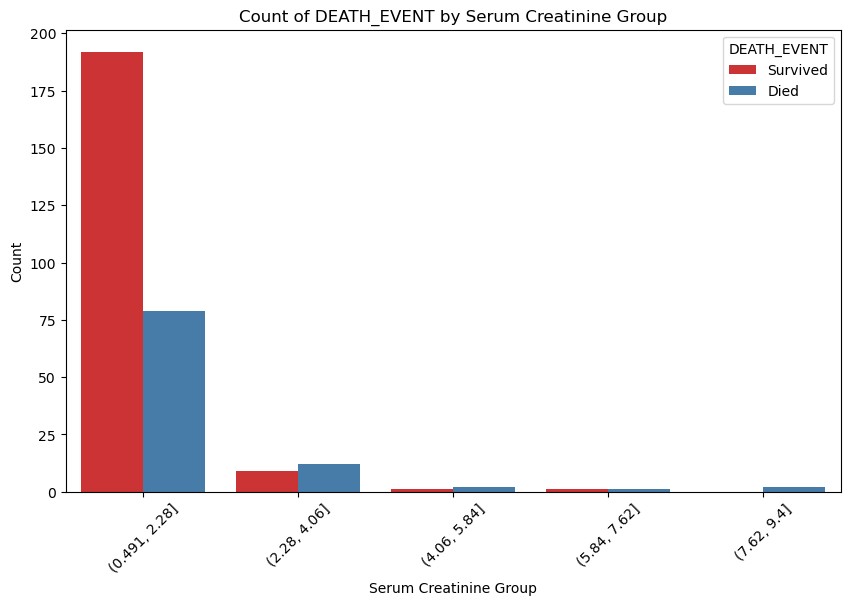

In [20]:
# Cross-tabulation of DEATH_EVENT and serum_creatinine
cross_tab_sc = pd.crosstab(df['DEATH_EVENT'], pd.cut(df['serum_creatinine'], bins=5))

print(cross_tab_sc)

# Chi-square test
chi2_sc, p_sc, dof_sc, expected_sc = chi2_contingency(cross_tab_sc)
print(f"Chi-square value: {chi2_sc}")
print(f"P-value: {p_sc}")


plt.figure(figsize=(10, 6))
sns.countplot(data=df, x=pd.cut(df['serum_creatinine'], bins=5), hue='DEATH_EVENT', palette='Set1')
plt.title('Count of DEATH_EVENT by Serum Creatinine Group')
plt.xlabel('Serum Creatinine Group')
plt.ylabel('Count')
plt.legend(title='DEATH_EVENT', labels=['Survived', 'Died'])
plt.xticks(rotation=45)
plt.show()

### Ανάλυση της μεταβλητής serum_creatinine ως προγνωστικός παράγοντας

Υψηλά επίπεδα serum creatinine σχετίζονται με αυξημένο κίνδυνο θνησιμότητας σε ασθενείς με καρδιακή ανεπάρκεια. Η στατιστική σημαντικότητα υποστηρίζει αυτήν την συσχέτιση, με το τεστ chi-square να δείχνει ότι η συσχέτιση είναι στατιστικά σημαντική (χ^2 = 13.29, p = 0.0099).

Παρακάτω παρατίθεται ο πίνακας συνάφειας για τη μεταβλητή serum_creatinine και τον προσδιορισμό DEATH_EVENT:

| Διάστημα serum_creatinine | DEATH_EVENT = 0 | DEATH_EVENT = 1 |
|-----------------------------|-----------------|-----------------|
| (0.491, 2.28]               | 192             | 79              |
| (2.28, 4.06]                | 9               | 12              |
| (4.06, 5.84]                | 1               | 2               |
| (5.84, 7.62]                | 1               | 1               |
| (7.62, 9.4]                 | 0               | 2               |

**Στατιστική Σημαντικότητα:**
Το τεστ chi-square δείχνει στατιστικά σημαντική συσχέτιση μεταξύ της μεταβλητής serum_creatinine και της θνησιμότητας στο πλαίσιο της καρδιακής ανεπάρκειας (p = 0.0099).

**Συμπέρασμα:**
Οι ασθενείς με υψηλά επίπεδα serum creatinine φαίνεται να έχουν αυξημένη πιθανότητα θανάτου σε σύγκριση με αυτούς με χαμηλότερα επίπεδα serum creatinine.


# 5. DEATH_EVENT and Diabetes

diabetes       0   1
DEATH_EVENT         
0            118  85
1             56  40
Chi-square value: 0.0
P-value: 1.0


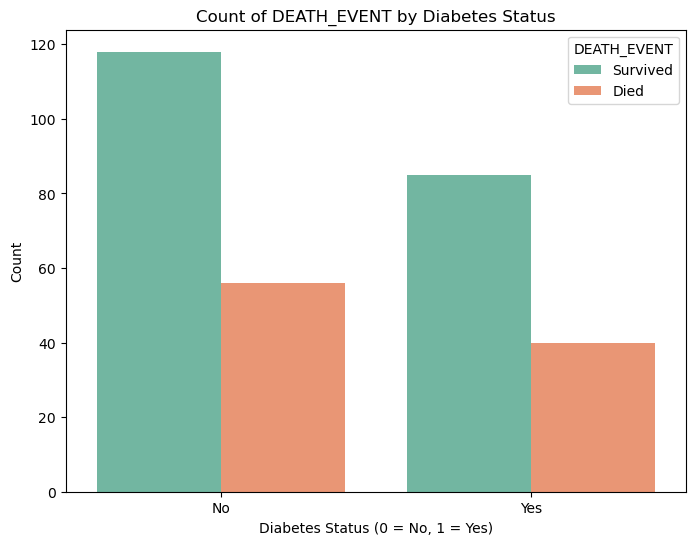

In [21]:
# Cross-tabulation of DEATH_EVENT and diabetes
cross_tab_diabetes = pd.crosstab(df['DEATH_EVENT'], df['diabetes'])

print(cross_tab_diabetes)

# Chi-square test
chi2_diabetes, p_diabetes, dof_diabetes, expected_diabetes = chi2_contingency(cross_tab_diabetes)
print(f"Chi-square value: {chi2_diabetes}")
print(f"P-value: {p_diabetes}")


plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='diabetes', hue='DEATH_EVENT', palette='Set2')
plt.title('Count of DEATH_EVENT by Diabetes Status')
plt.xlabel('Diabetes Status (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.legend(title='DEATH_EVENT', labels=['Survived', 'Died'])
plt.xticks([0, 1], ['No', 'Yes'])
plt.show()

### Ανάλυση της μεταβλητής Diabetes ως Προγνωστικός Παράγοντας

Βασισμένο στην ανάλυση, η διαβήτης δε φαίνεται να συσχετίζεται με αυξημένο κίνδυνο θνησιμότητας σε ασθενείς με καρδιακή ανεπάρκεια . Η στατιστική σημαντικότητα υποδεικνύει ότι οι παρατηρούμενες διαφορές στα ποσοστά θανάτου μεταξύ των ομάδων με και χωρίς διαβήτη είναι πιθανό να οφείλονται στην τυχαιότητα παρά σε μια σημαντική συσχέτιση.

Παρακάτω παρατίθεται ο πίνακας συνάφειας για τη μεταβλητή diabetes και τον προσδιορισμό DEATH_EVENT:

| Διαβήτης | DEATH_EVENT = 0 | DEATH_EVENT = 1 |
|-----------|-----------------|-----------------|
| 0         | 118             | 56              |
| 1         | 85              | 40              |

**Στατιστική Σημαντικότητα:**
Το υψηλό p-value (p = 1.0) υποδεικνύει ότι δεν υπάρχει στατιστικά σημαντική συσχέτιση μεταξύ της μεταβλητής diabetes και της θνησιμότητας στο πλαίσιο της καρδιακής ανεπάρκειας.

**Συμπέρασμα:**
Η διαβήτης δε φαίνεται να είναι σημαντικός προγνωστικός παράγοντας για τη θνησιμότητα σε ασθενείς με καρδιακή ανεπάρκεια .


# 6. DEATH_EVENT and Anaemia

anaemia        0   1
DEATH_EVENT         
0            120  83
1             50  46
Chi-square value: 1.042175485287005
P-value: 0.3073160508415107


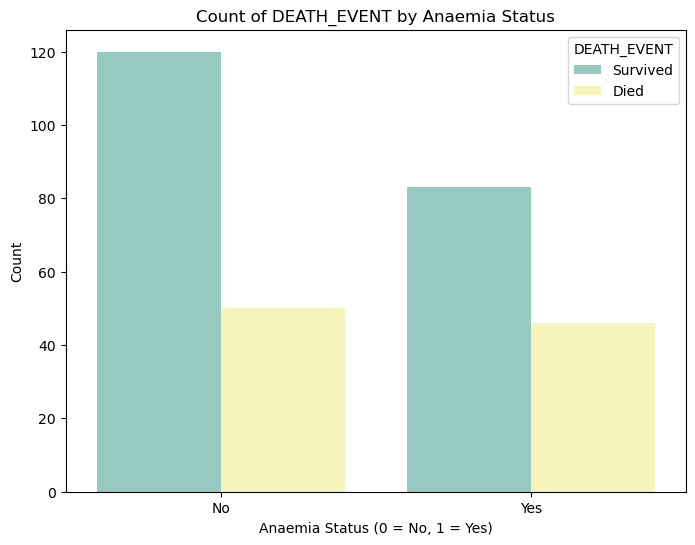

In [22]:
# Cross-tabulation of DEATH_EVENT and anaemia
cross_tab_anaemia = pd.crosstab(df['DEATH_EVENT'], df['anaemia'])

print(cross_tab_anaemia)

# Chi-square test
chi2_anaemia, p_anaemia, dof_anaemia, expected_anaemia = chi2_contingency(cross_tab_anaemia)
print(f"Chi-square value: {chi2_anaemia}")
print(f"P-value: {p_anaemia}")


plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='anaemia', hue='DEATH_EVENT', palette='Set3')
plt.title('Count of DEATH_EVENT by Anaemia Status')
plt.xlabel('Anaemia Status (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.legend(title='DEATH_EVENT', labels=['Survived', 'Died'])
plt.xticks([0, 1], ['No', 'Yes'])
plt.show()

### Ανάλυση της μεταβλητής Anaemia ως Προγνωστικός Παράγοντας

Βασισμένο στην ανάλυση, η αναιμία δε φαίνεται να συσχετίζεται με αυξημένο κίνδυνο θνησιμότητας σε ασθενείς με καρδιακή ανεπάρκεια . Η στατιστική σημαντικότητα υποδεικνύει ότι οι παρατηρούμενες διαφορές στα ποσοστά θανάτου μεταξύ των ομάδων με και χωρίς αναιμία είναι πιθανό να οφείλονται στην τυχαιότητα.

Παρακάτω παρατίθεται ο πίνακας συνάφειας για τη μεταβλητή anaemia και τον προσδιορισμό DEATH_EVENT:

| Αναιμία | DEATH_EVENT = 0 | DEATH_EVENT = 1 |
|-----------|-----------------|-----------------|
| 0         | 120             | 50              |
| 1         | 83              | 46              |

**Στατιστική Σημαντικότητα:**
Το υψηλό p-value (p = 0.3073) υποδεικνύει ότι δεν υπάρχει στατιστικά σημαντική συσχέτιση μεταξύ της μεταβλητής anaemia και της θνησιμότητας στο πλαίσιο της καρδιακής ανεπάρκειας.

**Συμπέρασμα:**
Η αναιμία δε φαίνεται να είναι σημαντικός προγνωστικός παράγοντας για τη θνησιμότητα σε ασθενείς με καρδιακή ανεπάρκεια .


# 6. DEATH_EVENT and Platelets

platelets    (24275.1, 190080.0]  (190080.0, 355060.0]  (355060.0, 520040.0]  \
DEATH_EVENT                                                                    
0                             35                   141                    23   
1                             20                    62                    13   

platelets    (520040.0, 685020.0]  (685020.0, 850000.0]  
DEATH_EVENT                                              
0                               2                     2  
1                               1                     0  
Chi-square value: 1.897950781408241
P-value: 0.7545214310385314


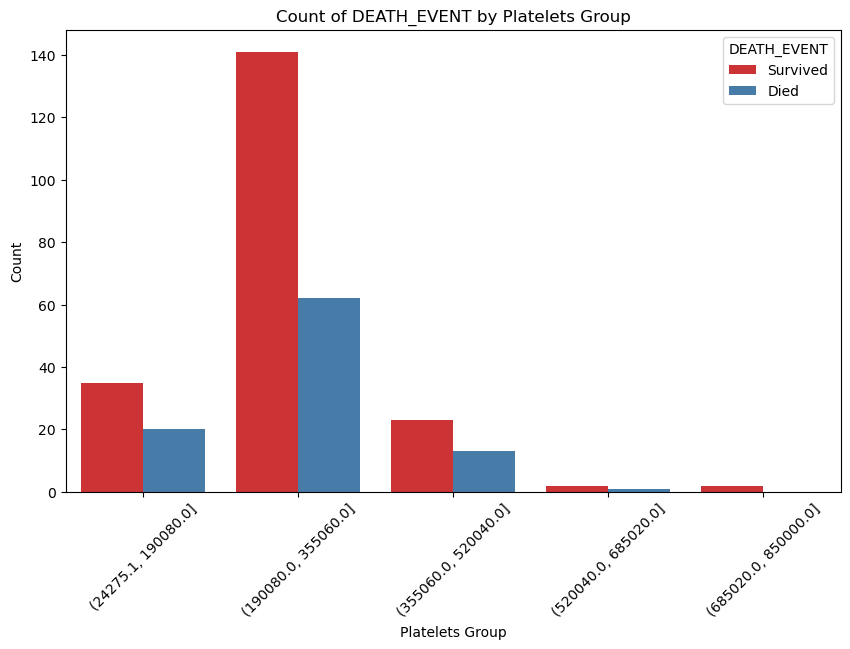

In [23]:
# Cross-tabulation of DEATH_EVENT and platelets
cross_tab_platelets = pd.crosstab(df['DEATH_EVENT'], pd.cut(df['platelets'], bins=5))

print(cross_tab_platelets)

# Chi-square test
chi2_platelets, p_platelets, dof_platelets, expected_platelets = chi2_contingency(cross_tab_platelets)
print(f"Chi-square value: {chi2_platelets}")
print(f"P-value: {p_platelets}")




plt.figure(figsize=(10, 6))
sns.countplot(data=df, x=pd.cut(df['platelets'], bins=5), hue='DEATH_EVENT', palette='Set1')
plt.title('Count of DEATH_EVENT by Platelets Group')
plt.xlabel('Platelets Group')
plt.ylabel('Count')
plt.legend(title='DEATH_EVENT', labels=['Survived', 'Died'])
plt.xticks(rotation=45)
plt.show()


### Ανάλυση της μεταβλητής Platelets ως Προγνωστικός Παράγοντας

Βασισμένο στην ανάλυση, οι επίπεδοι αιμοπεταλίων δε φαίνεται να συσχετίζονται με τον κίνδυνο θνησιμότητας σε ασθενείς με καρδιακή ανεπάρκεια . Η στατιστική σημαντικότητα υποδεικνύει ότι οι παρατηρούμενες διαφορές στα ποσοστά θανάτου μεταξύ των διαφορετικών επιπέδων αιμοπεταλίων είναι πιθανό να οφείλονται στην τυχαιότητα.

Παρακάτω παρατίθεται ο πίνακας συνάφειας για τη μεταβλητή platelets και τον προσδιορισμό DEATH_EVENT:

| Αιμοπετάλια | DEATH_EVENT = 0 | DEATH_EVENT = 1 |
|---------------|-----------------|-----------------|
| (24275.1, 190080.0]     | 35              | 20              |
| (190080.0, 355060.0]    | 141             | 62              |
| (355060.0, 520040.0]    | 23              | 13              |
| (520040.0, 685020.0]    | 2               | 1               |
| (685020.0, 850000.0]    | 2               | 0               |

**Στατιστική Σημαντικότητα:**
Το υψηλό p-value (p = 0.7545) υποδεικνύει ότι δεν υπάρχει στατιστικά σημαντική συσχέτιση μεταξύ των επιπέδων αιμοπεταλίων και της θνησιμότητας στο πλαίσιο της καρδιακής ανεπάρκειας.

**Συμπέρασμα:**
Τα επίπεδα αιμοπεταλίων δε φαίνεται να είναι σημαντικός προγνωστικός παράγοντας για τη θνησιμότητα σε ασθενείς με καρδιακή ανεπάρκεια.


# 7. DEATH_EVENT and High Blood Pressure

In [30]:
# Cross-tabulation of DEATH_EVENT and high_blood_pressure
cross_tab_hbp = pd.crosstab(df['DEATH_EVENT'], df['high_blood_pressure'])

print(cross_tab_hbp)

# Chi-square test
chi2_hbp, p_hbp, dof_hbp, expected_hbp = chi2_contingency(cross_tab_hbp)
print(f"Chi-square value: {chi2_hbp}")
print(f"P-value: {p_hbp}")


high_blood_pressure    0   1
DEATH_EVENT                 
0                    137  66
1                     57  39
Chi-square value: 1.5434607612967581
P-value: 0.21410341199416902


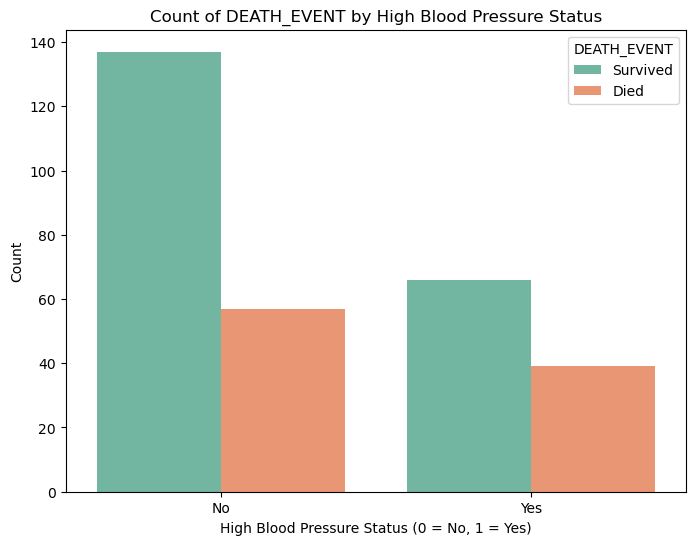

In [31]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='high_blood_pressure', hue='DEATH_EVENT', palette='Set2')
plt.title('Count of DEATH_EVENT by High Blood Pressure Status')
plt.xlabel('High Blood Pressure Status (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.legend(title='DEATH_EVENT', labels=['Survived', 'Died'])
plt.xticks([0, 1], ['No', 'Yes'])
plt.show()


# Σύνοψη Ευρημάτων:
### Ανάλυση της μεταβλητής High Blood Pressure ως Προγνωστικός Παράγοντας

Βασισμένο στην ανάλυση, η υψηλή αρτηριακή πίεση δε φαίνεται να συσχετίζεται με τον κίνδυνο θνησιμότητας σε ασθενείς με καρδιακή ανεπάρκεια . Η στατιστική σημαντικότητα υποδεικνύει ότι οι παρατηρούμενες διαφορές στα ποσοστά θανάτου μεταξύ ασθενών με και χωρίς υψηλή αρτηριακή πίεση μπορεί να οφείλονται στην τυχαιότητα.

Παρακάτω παρατίθεται ο πίνακας συνάφειας για τη μεταβλητή high_blood_pressure και τον προσδιορισμό DEATH_EVENT:

| Υψηλή Αρτηριακή Πίεση | DEATH_EVENT = 0 | DEATH_EVENT = 1 |
|------------------------|-----------------|-----------------|
| 0                      | 137             | 57              |
| 1                      | 66              | 39              |

**Στατιστική Σημαντικότητα:**
Το υψηλό p-value (p = 0.2141) υποδεικνύει ότι δεν υπάρχει στατιστικά σημαντική συσχέτιση μεταξύ της υψηλής αρτηριακής πίεσης και της θνησιμότητας στο πλαίσιο της καρδιακής ανεπάρκειας.

**Συμπέρασμα:**
Η υψηλή αρτηριακή πίεση δε φαίνεται να είναι σημαντικός προγνωστικός παράγοντας για τη θνησιμότητα σε ασθενείς με καρδιακή ανεπάρκεια .


In [54]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [55]:
import pandas as pd

# Example dataframe with ages
data = {
    'age': [45, 65, 78, 55, 60, 72, 50, 40, 68, 75]
}

df = pd.DataFrame(data)

# Define bins and labels for age groups
bins = [0, 50, 60, 70, 80, 100]  # Define your age bins here
labels = ['0-50', '51-60', '61-70', '71-80', '81-100']  # Labels for each age group

# Create a new column 'age_group' based on bins
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

# Convert 'age_group' into numerical categories
df['age_category'], _ = pd.factorize(df['age_group'])

# Drop the original 'age' and 'age_group' columns if needed
df.drop(columns=['age', 'age_group'], inplace=True)

# Print the transformed dataframe
print(df)


   age_category
0             0
1             1
2             2
3             3
4             1
5             2
6             3
7             0
8             1
9             2


In [57]:
import pandas as pd

# Example dataframe with platelets and serum_creatinine columns
data = {
    'platelets': [200000, 300000, 150000, 500000, 250000],
    'serum_creatinine': [1.2, 2.5, 1.5, 0.8, 1.0]
}

df = pd.DataFrame(data)

# Define bins and labels for platelets
platelets_bins = [0, 200000, 400000, 600000]  # Define your platelets bins here
platelets_labels = ['Low', 'Medium', 'High']  # Labels for platelets categories

# Define bins and labels for serum_creatinine
creatinine_bins = [0, 1.0, 2.0, 3.0, 5.0]  # Define your serum_creatinine bins here
creatinine_labels = ['Low', 'Medium', 'High', 'Very High']  # Labels for serum_creatinine categories

# Create new columns based on bins
df['platelets_category'] = pd.cut(df['platelets'], bins=platelets_bins, labels=platelets_labels, right=False)
df['creatinine_category'] = pd.cut(df['serum_creatinine'], bins=creatinine_bins, labels=creatinine_labels, right=False)

# Convert categorical columns into numerical categories
df['platelets_numeric'], _ = pd.factorize(df['platelets_category'])
df['creatinine_numeric'], _ = pd.factorize(df['creatinine_category'])

# Drop the original columns if needed
df.drop(columns=['platelets', 'serum_creatinine', 'platelets_category', 'creatinine_category'], inplace=True)

# Print the transformed dataframe
print(df)


   platelets_numeric  creatinine_numeric
0                  0                   0
1                  0                   1
2                  1                   0
3                  2                   2
4                  0                   0


# ΧΡΗΣΗ ΜΟΝΤΕΛΟΥ ΛΟΓΙΣΤΙΚΗΣ ΠΑΛΙΝΔΡΟΜΗΣΗΣ

In [29]:
# Logistic Regression

# Selecting features and target variable
X = df[['age', 'creatinine_phosphokinase', 'ejection_fraction', 'platelets', 'serum_creatinine', 'serum_sodium', 'time']]
y = df['DEATH_EVENT']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the logistic regression model
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

# Make predictions on the testing set
y_pred = log_reg.predict(X_test)



# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(class_report)




Accuracy: 0.8
Confusion Matrix:
[[34  1]
 [11 14]]

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.97      0.85        35
           1       0.93      0.56      0.70        25

    accuracy                           0.80        60
   macro avg       0.84      0.77      0.77        60
weighted avg       0.83      0.80      0.79        60



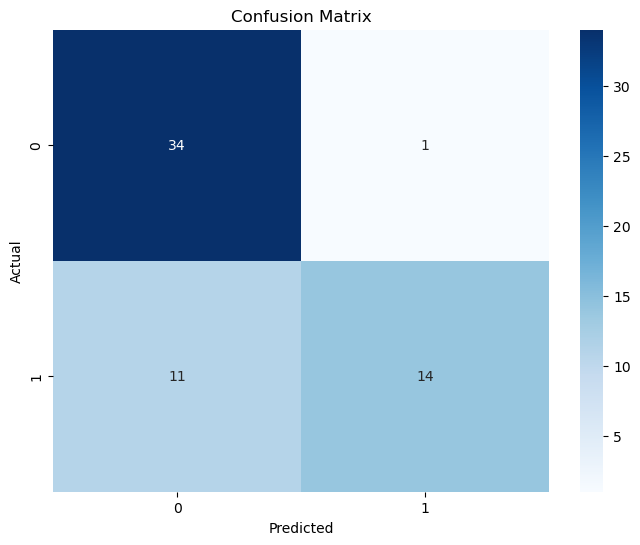

In [26]:
# Plotting the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

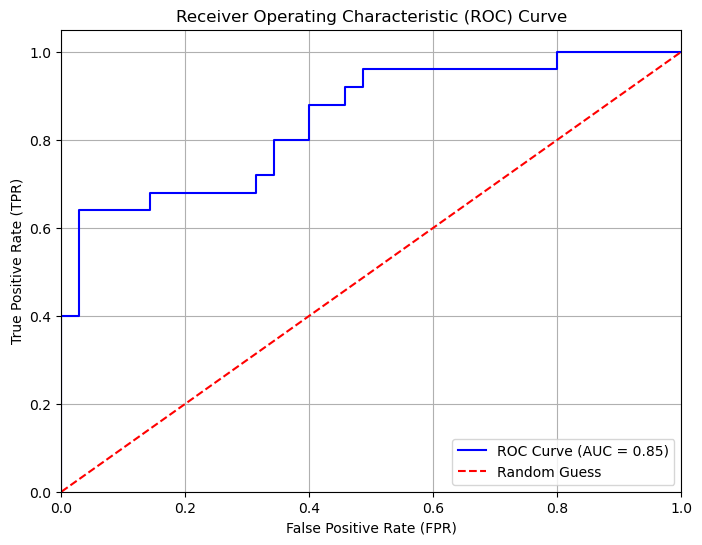

In [28]:
# Εισαγωγή των απαραίτητων βιβλιοθηκών
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Υπολογισμός των προβλέψεων πιθανοτήτων για το σύνολο δεδομένων ελέγχου
y_pred_proba = log_reg.predict_proba(X_test)[:, 1]

# Υπολογισμός της ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Υπολογισμός του ROC AUC
roc_auc = roc_auc_score(y_test, y_pred_proba)

# Σχεδίαση της ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


## Αποτελέσματα Λογιστικής Παλινδρόμησης

Το μοντέλο λογιστικής παλινδρόμησης παρουσίασε τα ακόλουθα αποτελέσματα:

- **Ακρίβεια (Accuracy):** 0.80

###  (Confusion Matrix)

| Προβλεπόμενη \ Πραγματική | Όχι (0) | Ναι (1) |
|--------------------------|---------|---------|
| Όχι (0)                  | 34      | 1       |
| Ναι (1)                  | 11      | 14      |

### Αναφορά Κατηγοριοποίησης (Classification Report)

|           | precision | recall | f1-score | support |
|-----------|-----------|--------|----------|---------|
| Όχι (0)   | 0.76      | 0.97   | 0.85     | 35      |
| Ναι (1)   | 0.93      | 0.56   | 0.70     | 25      |
| Μέση (avg)| 0.83      | 0.80   | 0.79     | 60      |

Τα αποτελέσματα δείχνουν ότι το μοντέλο έχει καλή ακρίβεια στην πρόβλεψη της κατηγορίας "Όχι" (0), ενώ η ακρίβεια είναι λίγο χαμηλότερη στην κατηγορία "Ναι" (1). Ο μέσος όρος (weighted avg) για το f1-score είναι 0.79, υποδεικνύοντας μια καλή ισορροπία μεταξύ ακρίβειας και ανάκλησης στο σύνολο δεδομένων δοκιμής.


# RESOURCES

1)P. Bagkos, "Special Topics in Biostatistics" Course Notes (2023-2024), University of Thessaly.

2)Heart Failure Clinical Records [Dataset]. (2020). UCI Machine Learning Repository. 

3)Schober, P., & Vetter, T. R. (2021). Logistic Regression in Medical Research

4)Chicco, D., & Jurman, G. (2020). Machine learning can predict survival of patients with heart failure from serum creatinine and ejection fraction alone. BMC Medical Informatics and Decision Making, 20.
The full code developed in the Jupyter notebook can be found here: HEART_FAILURE_FINAL